In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import io
import base64
from IPython.display import HTML, display

In [2]:
from IPython.display import HTML, display

global_reveal_fix = """
<style>
    /* 1. Reset Reveal's bounding box so it scales properly */
    .reveal .slides section {
        height: 100% !important;
        overflow: hidden !important; 
    }
    
    /* 2. Convert massive absolute paddings into responsive percentages */
    div[class^="slide-container"] {
        min-height: 0 !important;
        height: 100% !important; 
        padding: 4% 6% !important; /* Squishes the empty space */
        margin: 0 auto !important;
        box-sizing: border-box !important;
        display: flex !important;
        flex-direction: column !important;
        justify-content: center !important;
    }

    /* 3. Globally shrink typography and gaps that are pushing content down */
    [class*="-title"], .challenge-question {
        font-size: 2.2em !important; /* Down from 3.5em */
        margin-bottom: 15px !important;
        line-height: 1.1 !important;
    }
    
    .takeaways-container, .bullets-container {
        gap: 15px !important; /* Down from 40px */
    }

    .bullet-item, .takeaway-content, .takeaway-icon {
        font-size: 1.25em !important; /* Down from 1.6em */
    }

    /* 4. Force Charts to shrink instead of overflowing */
    .viz-wrapper {
        flex: 1 1 auto !important; /* Tells the container it is allowed to shrink */
        min-height: 0 !important;  /* Critical flexbox fix for overflowing content */
        display: flex !important;
        align-items: center !important;
        justify-content: center !important;
        margin: 10px 0 !important;
    }

    .viz-wrapper img {
        max-height: 100% !important; 
        width: auto !important;
        object-fit: contain !important;
    }

    /* 5. Force Photo Grids (Luther/Coffeehouse) to shrink */
    .tradeoff-grid {
        flex: 1 1 auto !important;
        min-height: 0 !important;
        margin: 10px 0 !important;
    }
    
    .image-row {
        height: auto !important;
        gap: 10px !important;
    }
    
    .gallery-img {
        max-height: 16vh !important; /* Ties image height directly to screen height */
        min-height: 0 !important;
        width: 100% !important;
        object-fit: cover !important;
    }

    /* 6. Tighten the synthesis banner */
    .synthesis-banner {
        margin-top: auto !important;
        padding: 15px !important;
    }
</style>
"""

display(HTML(global_reveal_fix))

In [4]:
# Defining the "Civic Commons" CSS and Title Slide HTML
civic_commons_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    /* Background and Container */
    .title-slide-container {
        background-color: #FDFCF8;
        border: 2px solid #2D5A27;
        padding: 80px 40px;
        text-align: center;
        border-radius: 12px;
        box-shadow: 0 10px 30px rgba(0,0,0,0.05);
        font-family: 'Inter', sans-serif;
        margin: 20px;
    }

    /* Main Title - Serif for authority */
    .title-slide-container h1 {
        font-family: 'Playfair Display', serif;
        color: #1A1A1A;
        font-size: 3.0em;
        margin-bottom: 0.2em;
        line-height: 1.1;
    }

    /* Subtitle - Clean Sans-serif */
    .title-slide-container h2 {
        color: #2D5A27;
        font-size: 1.8\3em;
        font-weight: 600;
        margin-top: 0;
        letter-spacing: -0.5px;
    }

    /* Decorative Divider */
    .civic-divider {
        width: 120px;
        height: 4px;
        background-color: #E2725B; /* Terracotta Accent */
        margin: 40px auto;
        border-radius: 2px;
    }

    /* Presenter Info */
    .presenter-info {
        font-size: 1.2em;
        color: #555;
        margin-top: 30px;
    }

    /* Tagline or Date */
    .presentation-footer {
        font-size: 0.9em;
        color: #888;
        text-transform: uppercase;
        letter-spacing: 2px;
        margin-top: 60px;
    }
</style>

<div class="title-slide-container">
    <h1>Beyond the Echo Chamber</h1>
    <h2>Virtual Labs for Better Policy and Public Debate</h2>
    
    <div class="civic-divider"></div>
    
    <div class="presenter-info">
        <strong>Thomas D. Pike, PhD</strong><br>
        Next Generation Governance & Democracy 3.0
    </div>
    
    <div class="presentation-footer">
        March 2026
    </div>
</div>
"""

HTML(civic_commons_html)

In [5]:
hook_slide_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .hook-container {
        background-color: #FDFCF8;
        border-left: 10px solid #E2725B; /* Terracotta accent for the hook */
        padding: 60px;
        text-align: left;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
    }

    .book-citation {
        font-size: 1.1em;
        color: #555;
        margin-bottom: 40px;
        line-height: 1.6;
        border-bottom: 1px solid #E0DED7;
        padding-bottom: 20px;
    }

    .book-title {
        font-family: 'Playfair Display', serif;
        font-style: italic;
        color: #2D5A27;
        font-weight: 700;
    }

    .hook-question-container {
        margin-top: 50px;
        text-align: center;
    }

    .hook-question {
        font-family: 'Playfair Display', serif;
        font-size: 3.2em;
        color: #1A1A1A;
        line-height: 1.2;
        margin: 0;
    }

    .context-tag {
        display: inline-block;
        background-color: #2D5A27;
        color: white;
        padding: 4px 12px;
        border-radius: 20px;
        font-size: 0.8em;
        text-transform: uppercase;
        letter-spacing: 1.5px;
        margin-bottom: 20px;
    }
</style>

<div class="hook-container">
    
    <div class="hook-question-container">
        <div class="hook-question">
            "How do you make a cult?"
        </div>
    </div>
</div>
"""


HTML(hook_slide_html)

In [6]:
def generate_individual_visualization():
    """Generates the dual visualization of diverse vs. closed feedback."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.patch.set_facecolor('#FDFCF8') # Match the Civic Commons background

    # --- Common Styling ---
    accent_green = '#2D5A27'
    accent_orange = '#E2725B'
    text_color = '#1A1A1A'
    font_family = 'sans-serif' # Simplified for the visual itself

    # Function to draw the individual
    def draw_person(ax, x, y, color):
        # Head
        circle = patches.Circle((x, y + 0.5), 0.2, color=color)
        ax.add_patch(circle)
        # Body (simple triangle/trapezoid)
        body = patches.Polygon([[x-0.2, y], [x+0.2, y], [x, y+0.4]], color=color)
        ax.add_patch(body)

    # --- Setup the Plot Axes ---
    for ax in axes:
        ax.set_xlim(0, 5)
        ax.set_ylim(0, 5)
        ax.axis('off')
        ax.set_aspect('equal')

    # ==========================================
    # LEFT PANEL: Diverse Information Ecosystem
    # ==========================================
    ax_left = axes[0]
    draw_person(ax_left, 2.5, 2.0, accent_green)
    
    ax_left.text(2.5, 4.5, "A. Open Governance (Diverse Feedback)", 
                 ha='center', fontsize=14, fontweight='bold', color=accent_green, fontfamily=font_family)

    # Different Source Indicators (abstract representations)
    # Scientific Data
    ax_left.annotate("Scientific\nData", xy=(2.5, 2.8), xytext=(2.5, 3.8),
                    arrowprops=dict(facecolor=accent_green, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)
    # Opposing Views
    ax_left.annotate("Opposing\nViews", xy=(2.2, 2.4), xytext=(0.8, 3.2),
                    arrowprops=dict(facecolor=accent_green, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)
    # Local Concerns
    ax_left.annotate("Local\nConcerns", xy=(2.8, 2.4), xytext=(4.2, 3.2),
                    arrowprops=dict(facecolor=accent_green, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)
    # Independent Press
    ax_left.annotate("Independent\nPress", xy=(2.3, 2.0), xytext=(1.0, 1.2),
                    arrowprops=dict(facecolor=accent_green, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)
    # Cross-Party Discourse
    ax_left.annotate("Cross-Party\nDiscourse", xy=(2.7, 2.0), xytext=(4.0, 1.2),
                    arrowprops=dict(facecolor=accent_green, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)

    # ==========================================
    # RIGHT PANEL: The Cult Echo Chamber
    # ==========================================
    ax_right = axes[1]
    draw_person(ax_right, 2.5, 2.0, accent_orange)
    
    ax_right.text(2.5, 4.5, "B. Cult (Single Feedback)", 
                  ha='center', fontsize=14, fontweight='bold', color=accent_orange, fontfamily=font_family)

    # The Single Source/Narrative (multiple arrows, same source)
    narrative_center = (2.5, 3.5)
       
    # Arrows confirming the narrative
    ax_right.annotate("Confirmation", xy=(2.3, 2.4), xytext=(1.0, 3.0),
                    arrowprops=dict(facecolor=accent_orange, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)
    
    # 2. Reinforcement (Top Right)
    ax_right.annotate("Reinforcement", xy=(2.7, 2.4), xytext=(4.0, 3.0),
                    arrowprops=dict(facecolor=accent_orange, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)
    
    # 3. Isolation (Bottom)
    ax_right.annotate("Isolation", xy=(2.5, 1.8), xytext=(2.5, 0.8),
                    arrowprops=dict(facecolor=accent_orange, shrink=0.05, width=2, headwidth=8),
                    ha='center', color=text_color, fontfamily=font_family)

    
    # Convert plot to Base64
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    data = base64.b64encode(buf.getvalue()).decode('utf-8')
    return f"data:image/png;base64,{data}"

# Generate the image data
individual_viz_base64 = generate_individual_visualization()

print("Visualization generated. Now run the HTML cell.")

Visualization generated. Now run the HTML cell.



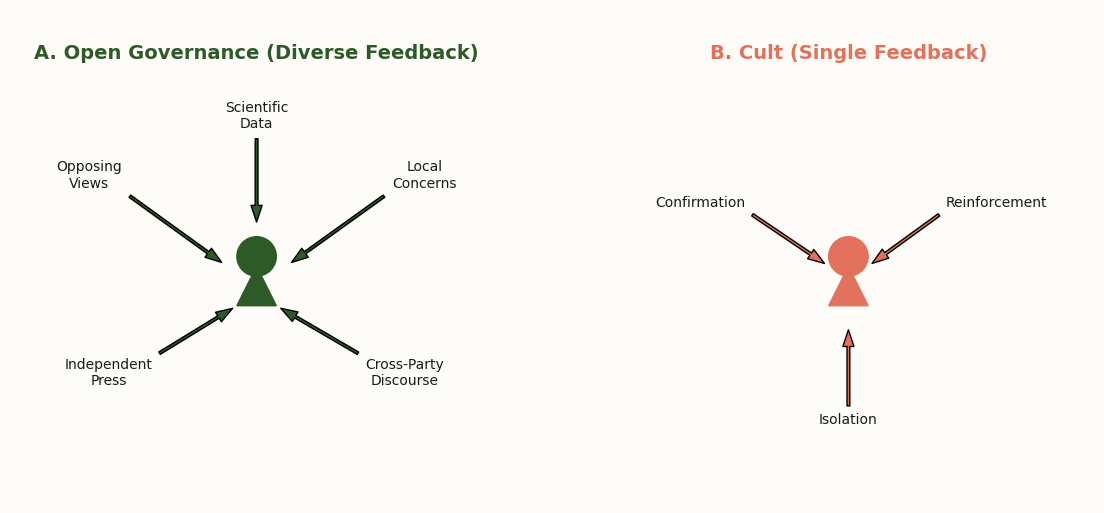

In [7]:
# We use .format() instead of an f-string to avoid the backslash/Base64 error
slide_template = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .slide-container-4 {{
        background-color: #FDFCF8;
        border-left: 10px solid #2D5A27;
        padding: 40px 60px;
        text-align: left;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        min-height: 580px;
        position: relative;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
    }}

    .process-header {{
        font-family: 'Playfair Display', serif;
        font-size: 1.8em;
        color: #1A1A1A;
        margin-bottom: 20px;
        border-bottom: 1px solid #E0DED7;
        padding-bottom: 10px;
    }}

    .viz-wrapper {{
        width: 100%;
        text-align: center;
        margin-top: 10px;
    }}
    
    .viz-wrapper img {{
        max-width: 90%;
        height: auto;
        border: 1px solid #E0DED7;
        border-radius: 8px;
    }}

    .citation-footer {{
        position: absolute;
        bottom: 10px;
        right: 40px;
        text-align: right;
        max-width: 500px;
    }}

    .turabian-note {{
        font-size: 0.6em;
        color: #666;
        line-height: 1.4;
        font-style: normal;
    }}
</style>

<div class="slide-container-4">
    <div class="process-header">Control the Information Sources</div>

    <div class="viz-wrapper">
        <img src="{img_data}" alt="Feedback Loop Visualization" />
    <div class="citation-footer">
        <div class="turabian-note">
            Anthony Pratkanis and Elliot Aronson, <i>Age of Propaganda: The Everyday Use and Abuse of Persuasion</i> (New York: Henry Holt and Company, 2001).
        </div>
    </div>

    
    </div>
</div>
"""

# Inject the image data safely
display(HTML(slide_template.format(img_data=individual_viz_base64)))

In [8]:
def generate_divergence_graph():
    # X-axis: Time from 1950 to 2026
    years = np.linspace(1950, 2026, 200)

    # 1. Proliferation of News Sources (Rising Logistic Curve)
    # Inflection point around 1995 (Internet), steepness = 0.15
    news_sigmoid = 1 / (1 + np.exp(-0.15 * (years - 1995)))
    # Scales the curve to start around 3 and end near 100
    news_sources = 3 + (news_sigmoid * 97)

    # 2. Societal Cohesion (Falling Logistic Curve)
    # Inflection point around 2005 (Social Media), steepness = 0.15
    cohesion_sigmoid = 1 / (1 + np.exp(-0.15 * (years - 2005)))
    # Scales the curve to start high (90) and drop low (20)
    societal_cohesion = 90 - (cohesion_sigmoid * 70)

    # Setup the plot with Civic Commons styling
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#FDFCF8')
    ax.set_facecolor('#FDFCF8')

    # Plot the lines
    # Terracotta for dropping cohesion, dark slate for rising noise
    ax.plot(years, societal_cohesion, color='#E2725B', linewidth=3.5, label='Societal Cohesion')
    ax.plot(years, news_sources, color='#1A202C', linewidth=3.5, label='Proliferation of News Sources')

    # Clean up the axes to look like a polished presentation slide
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    
    ax.set_xlim(1950, 2026)
    ax.set_ylim(0, 105)
    ax.set_yticks([])  # Hide y-axis numbers as the scale is conceptual
    
    # Custom x-axis ticks
    ax.set_xticks([1950, 1970, 1990, 2010, 2026])
    ax.set_xticklabels(['1950', '1970', '1990', '2010', 'Present'], fontsize=11, color='#555')

    # Add a clean legend
    ax.legend(frameon=False, fontsize=12, loc='center left')

    # Convert to Base64
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=150)
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

divergence_viz_base64 = generate_divergence_graph()
print("Divergence graph generated.")

Divergence graph generated.



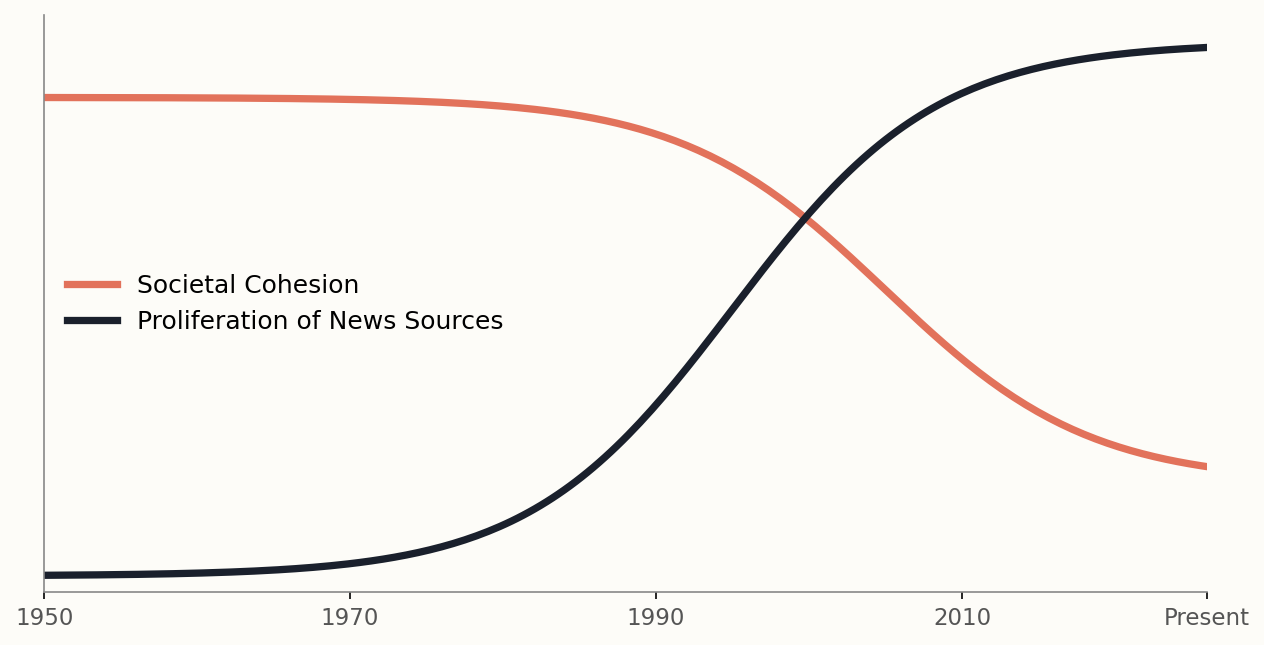

In [10]:
from IPython.display import HTML, display

slide_5_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .slide-container-5 {{
        background-color: #FDFCF8;
        border-left: 10px solid #1A202C; /* Dark slate to match the news proliferation line */
        padding: 40px 60px;
        text-align: left;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        min-height: 500px;
        position: relative;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
    }}

    .process-header {{
        font-family: 'Playfair Display', serif;
        font-size: 1.6em;
        color: #1A1A1A;
        margin-bottom: 10px;
    }}
    
    .process-subheader {{
        font-size: 0.7em;
        color: #555;
        margin-bottom: 30px;
        border-bottom: 1px solid #E0DED7;
        padding-bottom: 15px;
    }}

    .viz-wrapper {{
        width: 100%;
        text-align: center;
        margin-top: 10px;
    }}
    
    .viz-wrapper img {{
        max-width: 95%;
        height: auto;
    }}
</style>

<div class="slide-container-5">
    <div class="process-header">Echo Chambers and Cults of Self Selection</div>
    <div class="process-subheader">As the volume of customized information scales, shared societal reality fractures.</div>

    <div class="viz-wrapper">
        <img src="data:image/png;base64,{img_data}" alt="Line graph showing rising news sources and falling societal cohesion" />
    </div>
    <div class="citation-footer">
        <div class="turabian-note">
           This chart is not based on real data. 
        </div>
    </div>
</div>
"""

display(HTML(slide_5_html.format(img_data=divergence_viz_base64)))

In [11]:
slide_6_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .slide-container-6 {
        background-color: #FDFCF8;
        border-left: 10px solid #2D5A27; /* Green for structural balance */
        padding: 40px 60px;
        text-align: left;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        min-height: 600px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        display: flex;
        flex-direction: column;
    }

    .process-header {
        font-family: 'Playfair Display', serif;
        font-size: 1.8em;
        color: #1A1A1A;
        margin-bottom: 5px;
    }

    .process-subheader {
        font-size: 0.6em;
        color: #555;
        margin-bottom: 30px;
        border-bottom: 1px solid #E0DED7;
        padding-bottom: 15px;
    }

    /* Split Layout for the Tradeoff */
    .tradeoff-grid {
        display: flex;
        gap: 40px;
        flex-grow: 1;
    }

    .tradeoff-column {
        flex: 1;
        display: flex;
        flex-direction: column;
        background: #ffffff;
        border: 1px solid #E0DED7;
        border-radius: 8px;
        padding: 20px;
        box-shadow: 0 2px 8px rgba(0,0,0,0.02);
    }

    .column-header {
        font-family: 'Playfair Display', serif;
        font-size: 1.3em;
        text-align: center;
        margin-bottom: 5px;
        font-weight: 700;
    }

    .column-sub {
        text-align: center;
        font-size: 0.6em;
        color: #666;
        margin-bottom: 20px;
        text-transform: uppercase;
        letter-spacing: 1px;
    }

    /* Colors for the specific sides */
    .diversity-header { color: #E2725B; } /* Terracotta for friction/energy */
    .unity-header { color: #1A202C; } /* Slate for structure/solidity */

    /* Image Gallery Styling */
    .image-row {
        display: flex;
        flex-direction: column;
        gap: 15px;
        /* Hard-cap the height so it cannot push the banner off the bottom of the slide */
        height: 350px; 
        margin-bottom: 20px;
    }

    .gallery-img {
        width: 100%;
        height: 50%; /* Forces each image to take up exactly half of the 350px container */
        min-height: 0; /* Critical: allows the image to shrink below its actual file size */
        object-fit: cover; 
        border-radius: 4px;
        border: 1px solid #E0DED7;
        filter: grayscale(20%);
    }

    /* Bottom Synthesis Banner */
    .synthesis-banner {
        margin-top: 30px;
        background-color: #2D5A27;
        color: white;
        text-align: center;
        padding: 15px;
        border-radius: 4px;
        font-size: 1.1em;
        font-weight: 600;
        letter-spacing: 0.5px;
    }
</style>

<div class="slide-container-6">
    <div class="process-header">The Tension</div>
    <div class="process-subheader">A thriving society requires both diverse ideas and the capacity for unified action.</div>

    <div class="tradeoff-grid">
        <div class="tradeoff-column">
            <div class="column-header diversity-header">Diversity of Thought</div>
            <div class="column-sub">Disruption, Reform & Innovation</div>
            <div class="image-row">
                <img src="Luther.jpeg" alt="Martin Luther posting the 95 Theses" class="gallery-img" style="object-position: top;">
                <img src="coffeehouse.jpg" alt="17th Century Coffeehouse" class="gallery-img">
            </div>
        </div>

        <div class="tradeoff-column">
            <div class="column-header unity-header">Unified Action</div>
            <div class="column-sub">Cohesion, Resilience & Scale</div>
            <div class="image-row">
                <img src="churchill-roosevelt.jpg" alt="Churchill and Roosevelt" class="gallery-img" style="object-position: top;">
                <img src="vaccines.jpg" alt="Vials of Vaccines" class="gallery-img">
            </div>
        </div>
    </div>
</div>
"""

# No .format() needed here since we are just passing standard HTML with local image links.
display(HTML(slide_6_html))

In [12]:
slide_7_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .slide-container-7 {
        background-color: #FDFCF8;
        border-left: 10px solid #2D5A27; 
        padding: 40px 60px;
        text-align: left;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        min-height: 550px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        display: flex;
        flex-direction: column;
    }

    .process-header {
        font-family: 'Playfair Display', serif;
        font-size: 1.7em;
        color: #1A1A1A;
        margin-bottom: 5px;
    }

    .process-subheader {
        font-size: 0.9em;
        color: #2D5A27; 
        font-family: 'Playfair Display', serif;
        font-style: italic;
        margin-bottom: 30px;
        border-bottom: 1px solid #E0DED7;
        padding-bottom: 15px;
    }

    /* Grid layout mapping directly to the previous Diversity/Unity slide */
    .concept-grid {
        display: flex;
        gap: 40px;
        flex-grow: 1;
    }

    .concept-column {
        flex: 1;
        display: flex;
        flex-direction: column;
        background: #ffffff;
        border: 1px solid #E0DED7;
        border-radius: 8px;
        padding: 25px;
        box-shadow: 0 2px 8px rgba(0,0,0,0.02);
        align-items: center;
    }

    .concept-title {
        font-family: 'Inter', sans-serif;
        font-size: 1.8em;
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 2px;
        margin-bottom: 10px;
    }

    /* Tying back to the color language of Slide 6 */
    .explore-title { color: #E2725B; } /* Terracotta for friction/chaos */
    .exploit-title { color: #1A202C; } /* Slate for cohesion/order */

    .concept-desc {
        text-align: center;
        font-size: 0.95em;
        color: #555;
        margin-bottom: 20px;
        text-transform: uppercase;
        letter-spacing: 1px;
    }

    .image-placeholder {
        width: 100%;
        flex-grow: 1;
        display: flex;
        justify-content: center;
        align-items: center;
        border-radius: 4px;
        overflow: hidden;
    }

    .gallery-img {
        width: 100%;
        height: 200px;
        object-fit: cover;
        border: 1px solid #E0DED7;
        border-radius: 4px;
    }

    /* Gradient Banner Representing the 'Edge' */
    .edge-banner {
        margin-top: 30px;
        background: linear-gradient(90deg, #E2725B 0%, #2D5A27 50%, #1A202C 100%);
        color: white;
        text-align: center;
        padding: 15px;
        border-radius: 4px;
        font-size: 1.1em;
        font-weight: 600;
        letter-spacing: 1px;
    }
</style>

<div class="slide-container-7">
    <div class="process-header">Abstracting to the Fundamental Science</div>
    <div class="process-subheader">Life Thrives at the Edge of Chaos</div>

    <div class="concept-grid">
        <div class="concept-column">
            <div class="concept-title explore-title">Explore</div>
            <div class="image-placeholder">
                <img src="explore.png" alt="A person looking at a wild terrain with many options" class="gallery-img" onerror="this.style.display='none'; this.parentNode.innerHTML='<em>[Insert Explore Image]</em>'">
            </div>
        </div>

        <div class="concept-column">
            <div class="concept-title exploit-title">Exploit</div>
            <div class="image-placeholder">
                <img src="exploit.png" alt="A person seeing one path to a single hill" class="gallery-img" onerror="this.style.display='none'; this.parentNode.innerHTML='<em>[Insert Exploit Image]</em>'">
            </div>
        </div>
    </div>

    <div class="edge-banner">
        The Challenge: Balancing Diversity of Ideas (Explore) and Unified Action (Exploit)
    </div>
</div>
"""

display(HTML(slide_7_html))

In [13]:
from IPython.display import HTML, display

slide_8_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .slide-container-8 {
        background-color: #FDFCF8;
        border-top: 10px solid #E2725B; /* Terracotta accent for emphasis */
        padding: 80px 60px;
        text-align: center;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        min-height: 400px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        display: flex;
        flex-direction: column;
        justify-content: center;
        align-items: center;
    }

    .challenge-label {
        font-size: 1.2em;
        color: #E2725B;
        text-transform: uppercase;
        letter-spacing: 3px;
        margin-bottom: 30px;
        font-weight: 600;
    }

    .challenge-question {
        font-family: 'Playfair Display', serif;
        font-size: 3.5em;
        color: #1A1A1A;
        line-height: 1.2;
        max-width: 900px;
    }
    
    .challenge-divider {
        width: 80px;
        height: 3px;
        background-color: #2D5A27; /* Green accent to tie back to governance */
        margin: 40px auto 0 auto;
    }
</style>

<div class="slide-container-8">
    <div class="challenge-label">The Challenge</div>
    <div class="challenge-question">
        How Does Democracy 3.0 Optimize Society's Information Dynamic?
    </div>
    <div class="challenge-divider"></div>
</div>
"""

display(HTML(slide_8_html))

In [14]:
from IPython.display import HTML, display

slide_9_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .slide-container-9 {
        background-color: #FDFCF8;
        border-left: 10px solid #2D5A27; /* Green for structural balance */
        padding: 60px;
        text-align: left;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        min-height: 500px;
        position: relative;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        display: flex;
        flex-direction: column;
    }

    .slide-title-9 {
        font-family: 'Playfair Display', serif;
        font-size: 1.5em;
        color: #1A1A1A;
        margin-bottom: 50px;
        line-height: 1.2;
        border-bottom: 2px solid #E0DED7;
        padding-bottom: 20px;
    }

    .bullets-container {
        display: flex;
        flex-direction: column;
        gap: 40px;
        padding-left: 20px;
        max-width: 900px;
    }

    .bullet-item {
        display: flex;
        align-items: flex-start;
        font-size: 1.0em;
        color: #1A202C;
        line-height: 1.4;
    }

    .bullet-icon {
        color: #E2725B; /* Terracotta accent for the bullets */
        margin-right: 20px;
        font-size: 1.2em;
        line-height: 1;
    }

    .prototype-link {
        color: #2D5A27;
        text-decoration: none;
        border-bottom: 2px solid #E2725B;
        transition: color 0.2s ease;
    }

    .prototype-link:hover {
        color: #E2725B;
    }

    .disclaimer-text {
        position: absolute;
        bottom: 20px;
        right: 40px;
        font-size: 0.9em;
        color: #666;
        font-style: italic;
    }
</style>

<div class="slide-container-9">
    <div class="slide-title-9">
        Policy Commons: Virtual Policy Labs To Explore<span style="color: #E2725B;">*</span>
    </div>
    
    <div class="bullets-container">
        <div class="bullet-item">
            <div class="bullet-icon">&bull;</div>
            <div>Virtually explore to find the path to exploit <strong>before</strong> allocating resources</div>
        </div>
        <div class="bullet-item">
            <div class="bullet-icon">&bull;</div>
            <div>Ground debate in valid simulations instead of just political marketing</div>
        </div>
        <div class="bullet-item">
            <div class="bullet-icon">&bull;</div>
            <div>A very initial prototype: <a href="https://inequality-simulator.onrender.com/" target="_blank" class="prototype-link">Inequality Simulator</a></div>
        </div>
    </div>

    <div class="disclaimer-text">
        * This represents one component of a needed multi-pronged solution.
    </div>
</div>
"""

display(HTML(slide_9_html))

In [15]:
from IPython.display import HTML, display

slide_10_html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,700&family=Inter:wght@400;600&display=swap" rel="stylesheet">

<style>
    .slide-container-10 {
        background-color: #FDFCF8;
        border-top: 10px solid #2D5A27; /* Green top border for conclusive structure */
        padding: 60px 80px;
        text-align: left;
        border-radius: 4px;
        font-family: 'Inter', sans-serif;
        margin: 20px;
        min-height: 500px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.05);
        display: flex;
        flex-direction: column;
    }

    .slide-title-10 {
        font-family: 'Playfair Display', serif;
        font-size: 1.8em;
        color: #1A1A1A;
        margin-bottom: 40px;
        line-height: 1.2;
        border-bottom: 2px solid #E0DED7;
        padding-bottom: 15px;
    }

    .takeaways-container {
        display: flex;
        flex-direction: column;
        gap: 35px;
    }

    .takeaway-item {
        display: flex;
        align-items: flex-start;
    }

    .takeaway-icon {
        color: #E2725B; /* Terracotta accent */
        font-size: 1.0em;
        margin-right: 20px;
        line-height: 1.2;
    }

    .takeaway-content {
        font-size: 1.0em;
        color: #1A202C;
        line-height: 1.5;
    }

    .takeaway-content strong {
        color: #1A1A1A;
        font-weight: 700;
    }

    .nested-list {
        margin-top: 15px;
        padding-left: 20px;
        list-style-type: none;
        display: flex;
        flex-direction: column;
        gap: 15px;
    }

    .nested-list li {
        position: relative;
        font-size: 0.85em;
        color: #444;
    }

    .nested-list li::before {
        position: absolute;
        left: -25px;
        color: #2D5A27; /* Green dash for sub-bullets */
        font-weight: bold;
    }
    
    .highlight-valid {
        color: #E2725B !important; 
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 0.5px;
    }

    .final-footer {
        margin-top: auto;
        text-align: center;
        padding-top: 40px;
        font-family: 'Playfair Display', serif;
        font-size: 1.4em;
        color: #2D5A27;
        font-style: italic;
    }
</style>

<div class="slide-container-10">
    <div class="slide-title-10">Going Beyond the Echo Chamber</div>
    
    <div class="takeaways-container">
        <div class="takeaway-item">
            <div class="takeaway-icon">&bull;</div>
            <div class="takeaway-content">
                The <strong>proliferation of information sources</strong> is a key driver of polarization through "self-selecting cults."
            </div>
        </div>

        <div class="takeaway-item">
            <div class="takeaway-icon">&bull;</div>
            <div class="takeaway-content">
                An ideal information environment balances a <strong>diversity of ideas</strong> and the capacity for <strong>unified action</strong>.
            </div>
        </div>

        <div class="takeaway-item">
            <div class="takeaway-icon">&bull;</div>
            <div class="takeaway-content">
                <strong>Policy Commons seeks to alter the information landscape:</strong>
                <ul class="nested-list">
                    <li>Through valid virtual labs that optimize virtual exploration before exploitation.</li>
                    <li>By grounding debate in <span class="highlight-valid">valid</span> simulations that facilitate the exchange of ideas.</li>
                </ul>
            </div>
        </div>
    </div>
    
    <div class="final-footer">
        Thank you.
    </div>
</div>
"""

display(HTML(slide_10_html))